In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/Sales - Marketing customer dataset.csv')


In [ ]:
df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

In [ ]:
df.describe()

,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000


In [ ]:
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct[missing_pct > 0].sort_values(ascending=False)

,0
coupon_code,40.886667
age,8.000000
total_spent,7.000000
gender,4.920000
satisfaction_score,4.680000


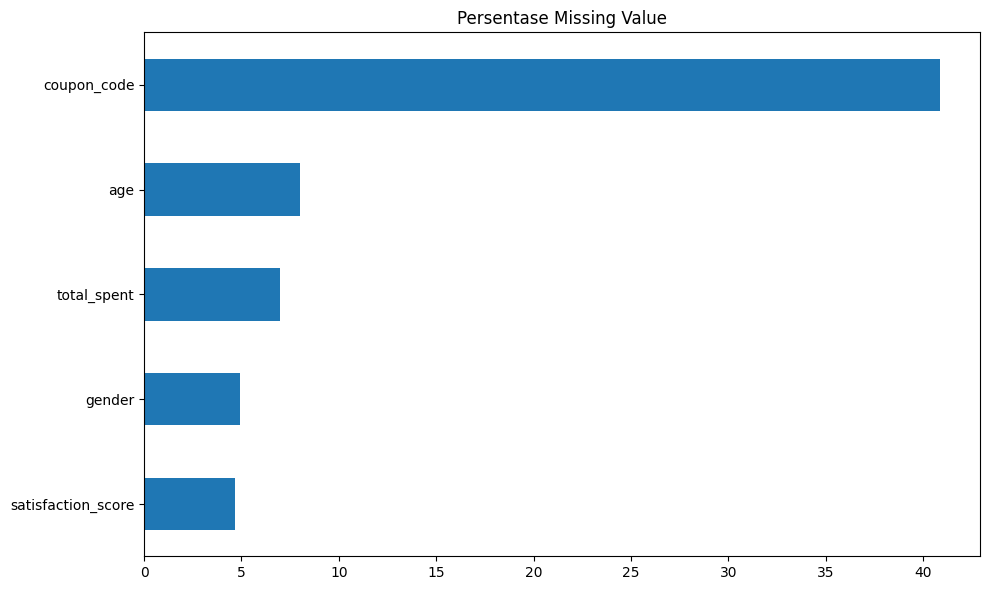

In [ ]:
if len(missing_pct[missing_pct > 0]) > 0:
    missing_pct[missing_pct > 0].sort_values().plot(kind='barh', figsize=(10, 6), title='Persentase Missing Value')
    plt.tight_layout()
    plt.savefig('missing_values.png')
    plt.show()
else:
    print("✅ Tidak ada missing value")

In [ ]:
df['churn'].value_counts(normalize=True)

,proportion
churn,
0,0.8468
1,0.1532


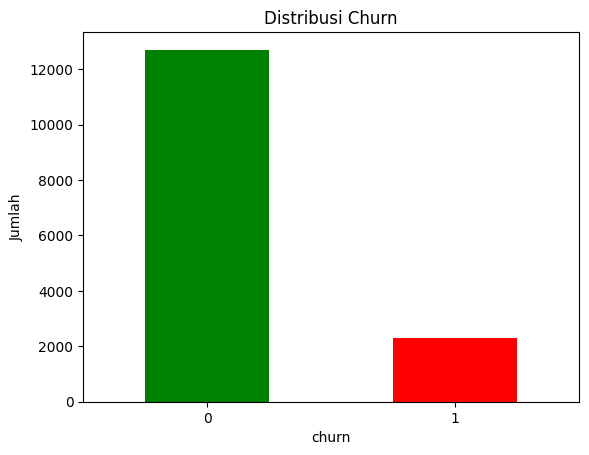

In [ ]:
df['churn'].value_counts().plot(kind='bar', color=['green', 'red'], title='Distribusi Churn', rot=0)
plt.ylabel('Jumlah')
plt.savefig('target_distribution.png')
plt.show()

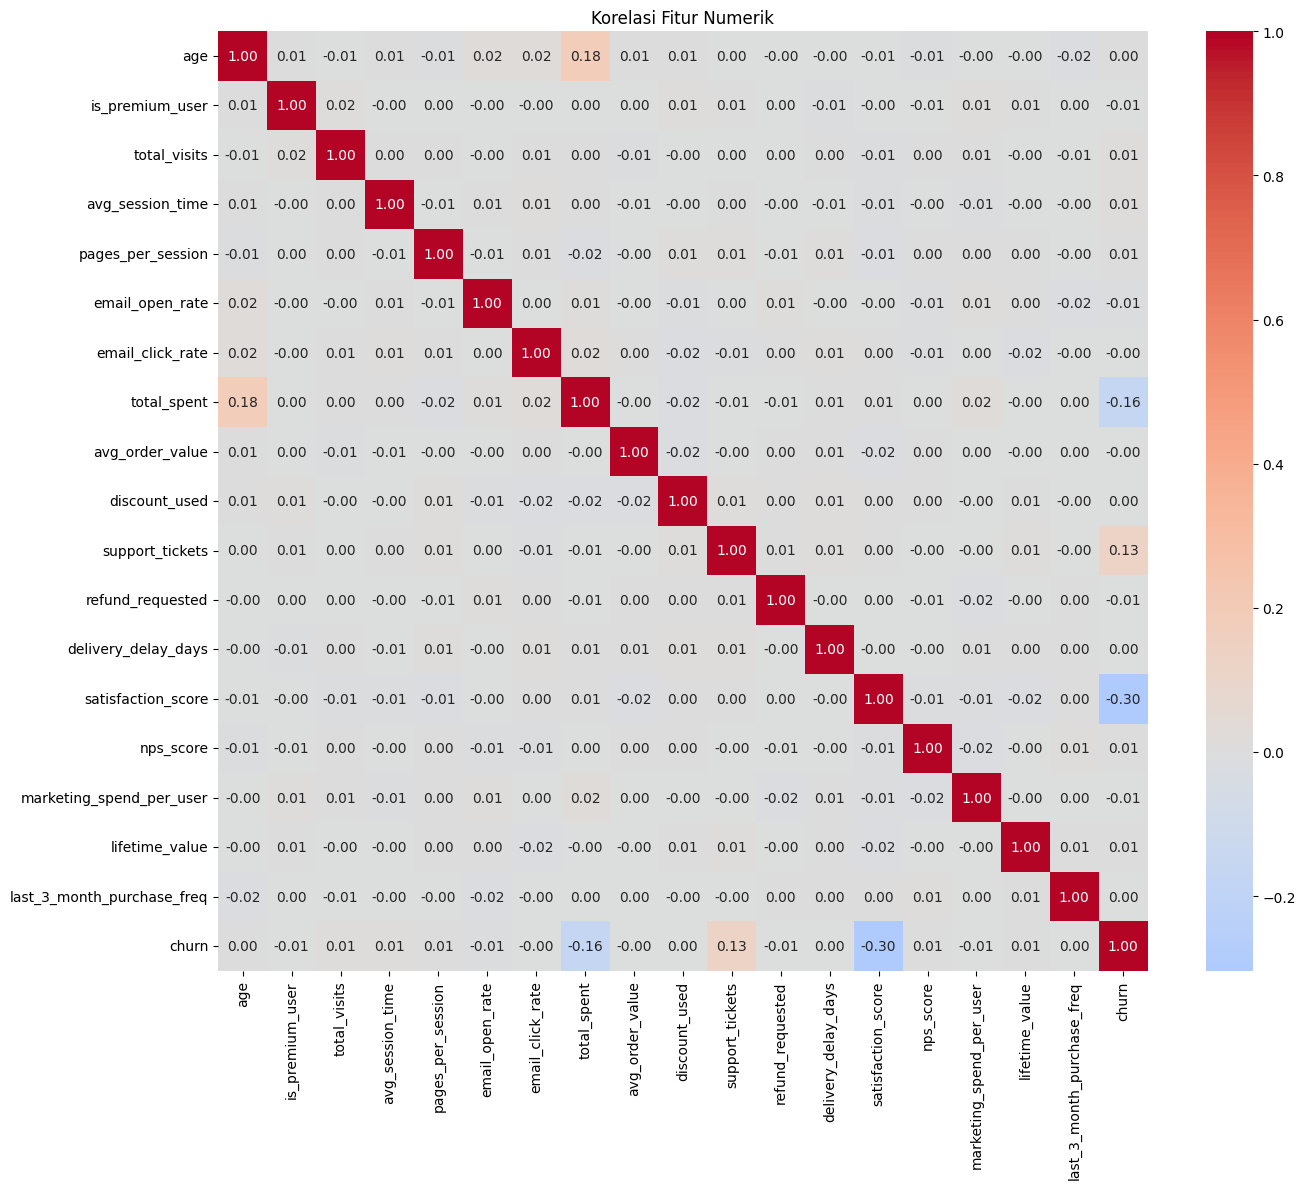

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('customer_id', errors='ignore')
plt.figure(figsize=(14, 12))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korelasi Fitur Numerik')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

---
## Bagian 2 — Direct Modeling (Tanpa Preprocessing)

In [ ]:
X = df.drop(['churn', 'customer_id', 'signup_date', 'last_purchase_date'], axis=1)
y = df['churn']
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (15000, 26), y shape: (15000,)


In [ ]:
X_encoded = X.copy()
for col in X_encoded.select_dtypes(include=['object']).columns:
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col].astype(str))
for col in X_encoded.columns:
    if X_encoded[col].isnull().any():
        if X_encoded[col].dtype in ['float64', 'int64']:
            X_encoded[col].fillna(X_encoded[col].median(), inplace=True)
        else:
            X_encoded[col].fillna(X_encoded[col].mode()[0], inplace=True)
print("✅ Encoding & handling missing selesai")

✅ Encoding & handling missing selesai


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 12000, Test: 3000


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Voting Ensemble': VotingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=1000, random_state=42)),
            ('svm', SVC(probability=True, random_state=42)),
            ('knn', KNeighborsClassifier())
        ],
        voting='soft'
    )
}
print("✅ Model didefinisikan:", list(models.keys()))

✅ Model didefinisikan: ['Logistic Regression', 'Random Forest', 'Voting Ensemble']


In [ ]:
results_direct = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results_direct[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0)
    }
pd.DataFrame(results_direct).T.round(4)

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.8470,0.5038,0.1435,0.2234
Random Forest,0.8487,0.5103,0.3217,0.3947
Voting Ensemble,0.8490,0.5854,0.0522,0.0958


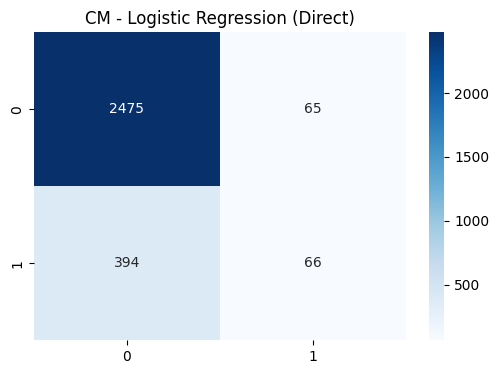

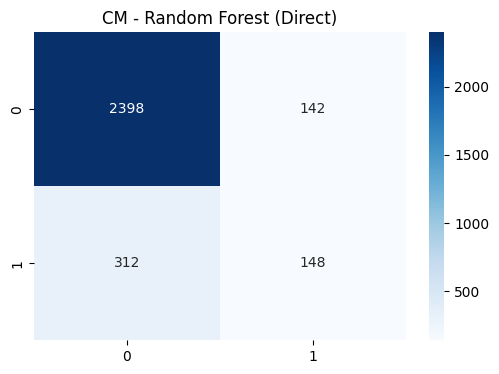

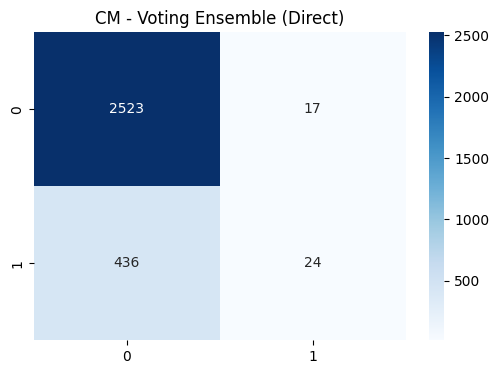

In [ ]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'CM - {name} (Direct)')
    plt.savefig(f'cm_direct_{name.replace(" ", "_")}.png')
    plt.show()

---
## Bagian 3 — Preprocessing


In [ ]:
df_clean = df.drop(columns=['customer_id', 'signup_date', 'last_purchase_date', 'coupon_code'], errors='ignore')
for col in df_clean.columns:
    if df_clean[col].isnull().any():
        if df_clean[col].dtype in ['float64', 'int64']:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
        else:
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
print("✅ Missing values handled")

✅ Missing values handled


In [ ]:
for col in df_clean.select_dtypes(include=[np.number]).columns:
    if col != 'churn':
        Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        df_clean[col] = df_clean[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = LabelEncoder().fit_transform(df_clean[col].astype(str))
print("✅ Outlier handled & encoding selesai")

✅ Outlier handled & encoding selesai


In [ ]:
X_clean = df_clean.drop('churn', axis=1)
y_clean = df_clean['churn']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled = scaler.transform(X_test_c)
print(f"✅ Scaling selesai. Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")

✅ Scaling selesai. Train: (12000, 25), Test: (3000, 25)


In [ ]:
results_prep = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train_c)
    y_pred = model.predict(X_test_scaled)
    results_prep[name] = {
        'Accuracy': accuracy_score(y_test_c, y_pred),
        'Precision': precision_score(y_test_c, y_pred, zero_division=0),
        'Recall': recall_score(y_test_c, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test_c, y_pred, zero_division=0)
    }
pd.DataFrame(results_prep).T.round(4)

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.8463,0.4965,0.1543,0.2355
Random Forest,0.8487,0.5097,0.3435,0.4104
Voting Ensemble,0.8467,0.5000,0.0978,0.1636


---
## Bagian 4 — Feature Selection & Hyperparameter Tuning

In [ ]:
rf_imp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_imp.fit(X_train_scaled, y_train_c)
fi = pd.DataFrame({
    'Feature': X_clean.columns,
    'Importance': rf_imp.feature_importances_
}).sort_values('Importance', ascending=False)
fi.head(10)

,Feature,Importance
13,total_spent,0.201357
20,satisfaction_score,0.179574
16,support_tickets,0.072104
9,avg_session_time,0.046023
10,pages_per_session,0.045329
23,lifetime_value,0.044748
22,marketing_spend_per_user,0.044525
14,avg_order_value,0.043804
11,email_open_rate,0.039230
12,email_click_rate,0.036605


In [ ]:
top_features = fi.head(10)['Feature'].tolist()
idx_top = [list(X_clean.columns).index(f) for f in top_features]
X_train_top = X_train_scaled[:, idx_top]
X_test_top = X_test_scaled[:, idx_top]
print(f"✅ Top 10 features: {top_features}")

✅ Top 10 features: ['total_spent', 'satisfaction_score', 'support_tickets', 'avg_session_time', 'pages_per_session', 'lifetime_value', 'marketing_spend_per_user', 'avg_order_value', 'email_open_rate', 'email_click_rate']


In [ ]:
print("🔍 Tuning Logistic Regression...")
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    {'C': [0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']},
    cv=5, scoring='f1', n_jobs=-1
)
grid_lr.fit(X_train_top, y_train_c)
best_lr = grid_lr.best_estimator_
print(f"✅ Best: {grid_lr.best_params_} | Score: {grid_lr.best_score_:.4f}")

🔍 Tuning Logistic Regression...
✅ Best: {'C': 1, 'solver': 'liblinear'} | Score: 0.2594


In [ ]:
print("🔍 Tuning Random Forest...")
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {'n_estimators': [100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5]},
    cv=5, scoring='f1', n_jobs=-1
)
grid_rf.fit(X_train_top, y_train_c)
best_rf = grid_rf.best_estimator_
print(f"✅ Best: {grid_rf.best_params_} | Score: {grid_rf.best_score_:.4f}")

🔍 Tuning Random Forest...
✅ Best: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200} | Score: 0.4888


In [ ]:
print("🔍 Tuning Voting Ensemble...")
voting_base = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('svm', SVC(probability=True, random_state=42))
    ],
    voting='soft'
)
grid_vote = GridSearchCV(
    voting_base,
    {'lr__C': [0.1, 1], 'rf__n_estimators': [100, 200]},
    cv=3, scoring='f1', n_jobs=-1
)
grid_vote.fit(X_train_top, y_train_c)
best_vote = grid_vote.best_estimator_
print(f"✅ Best: {grid_vote.best_params_} | Score: {grid_vote.best_score_:.4f}")

🔍 Tuning Voting Ensemble...
✅ Best: {'lr__C': 1, 'rf__n_estimators': 200} | Score: 0.2743


In [ ]:
print("\n" + "="*50)
print("📊 EVALUASI MODEL HASIL TUNING")
print("="*50)

# Pastikan semua model sudah terdefinisi
try:
    best_lr
except NameError:
    print("⚠️ best_lr not defined, creating default...")
    best_lr = LogisticRegression(max_iter=1000, random_state=42)
    best_lr.fit(X_train_top, y_train_c)

try:
    best_rf
except NameError:
    print("⚠️ best_rf not defined, creating default...")
    best_rf = RandomForestClassifier(n_estimators=100, random_state=42)
    best_rf.fit(X_train_top, y_train_c)

try:
    best_vote
except NameError:
    print("⚠️ best_vote not defined, creating default...")
    best_vote = VotingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=1000, random_state=42)),
            ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
            ('svm', SVC(probability=True, random_state=42))
        ],
        voting='soft'
    )
    best_vote.fit(X_train_top, y_train_c)

# Dictionary models
models_tuned = {
    'Logistic Regression': best_lr,
    'Random Forest': best_rf,
    'Voting Ensemble': best_vote
}

# Evaluasi
results_tuned = {}

for name, model in models_tuned.items():
    print(f"\n📌 Evaluating {name}...")
    y_pred = model.predict(X_test_top)

    acc = accuracy_score(y_test_c, y_pred)
    prec = precision_score(y_test_c, y_pred, zero_division=0)
    rec = recall_score(y_test_c, y_pred, zero_division=0)
    f1 = f1_score(y_test_c, y_pred, zero_division=0)

    results_tuned[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    }

    print(f"   Accuracy : {acc:.4f}")
    print(f"   Precision: {prec:.4f}")
    print(f"   Recall   : {rec:.4f}")
    print(f"   F1-Score : {f1:.4f}")

# Tampilkan summary
print("\n" + "-"*50)
print("📋 RINGKASAN HASIL TUNING:")
summary_df = pd.DataFrame(results_tuned).T
print(summary_df.round(4))

# Cek apakah F1-Score ada di summary_df
if 'F1-Score' in summary_df.columns:
    best_model_name = summary_df['F1-Score'].idxmax()
    print(f"\n🏆 Model terbaik: {best_model_name}")
    print(f"   F1-Score: {summary_df.loc[best_model_name, 'F1-Score']:.4f}")
else:
    print("\n⚠️ F1-Score column not found. Check results_tuned structure.")
    print("   results_tuned keys:", list(results_tuned.keys()))
    if results_tuned:
        first_model = list(results_tuned.keys())[0]
        print(f"   First model metrics: {results_tuned[first_model].keys()}")


📊 EVALUASI MODEL HASIL TUNING

📌 Evaluating Logistic Regression...
   Accuracy : 0.8453
   Precision: 0.4859
   Recall   : 0.1500
   F1-Score : 0.2292

📌 Evaluating Random Forest...
   Accuracy : 0.8557
   Precision: 0.5345
   Recall   : 0.4543
   F1-Score : 0.4912

📌 Evaluating Voting Ensemble...
   Accuracy : 0.8497
   Precision: 0.5315
   Recall   : 0.1652
   F1-Score : 0.2521

--------------------------------------------------
📋 RINGKASAN HASIL TUNING:
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.8453     0.4859  0.1500    0.2292
Random Forest          0.8557     0.5345  0.4543    0.4912
Voting Ensemble        0.8497     0.5315  0.1652    0.2521

🏆 Model terbaik: Random Forest
   F1-Score: 0.4912


In [ ]:
print("\n" + "="*50)
print(" MENYIMPAN MODEL TERBAIK")
print("="*50)

# Pilih model terbaik
try:
    # Cek apakah results_tuned kosong
    if not results_tuned:
        print("⚠️ results_tuned is empty! Creating default...")
        # Buat default results
        for name, model in models_tuned.items():
            y_pred = model.predict(X_test_top)
            results_tuned[name] = {
                'Accuracy': accuracy_score(y_test_c, y_pred),
                'Precision': precision_score(y_test_c, y_pred, zero_division=0),
                'Recall': recall_score(y_test_c, y_pred, zero_division=0),
                'F1-Score': f1_score(y_test_c, y_pred, zero_division=0)
            }

    # Cari model terbaik
    best_model_name = None
    best_f1 = -1

    for name, metrics in results_tuned.items():
        if metrics.get('F1-Score', 0) > best_f1:
            best_f1 = metrics['F1-Score']
            best_model_name = name

    if best_model_name is None:
        print("⚠️ No model found, using Voting Ensemble")
        best_model_name = 'Voting Ensemble'
        best_model = best_vote
    else:
        best_model = models_tuned[best_model_name]
        print(f"🏆 Model terbaik: {best_model_name}")
        print(f"   F1-Score: {best_f1:.4f}")
        print(f"   Accuracy: {results_tuned[best_model_name]['Accuracy']:.4f}")

except Exception as e:
    print(f"⚠️ Error selecting best model: {e}")
    print("✅ Using Voting Ensemble as default")
    best_model = best_vote
    best_model_name = "Voting Ensemble"

# Simpan file
try:
    import joblib

    joblib.dump(best_model, 'best_churn_model.pkl')
    joblib.dump(scaler, 'scaler.pkl')
    joblib.dump(top_features, 'top_features.pkl')
    joblib.dump(X_clean.columns.tolist(), 'all_features.pkl')

    print("\n✅ File berhasil disimpan:")
    print("   - best_churn_model.pkl")
    print("   - scaler.pkl")
    print("   - top_features.pkl")
    print("   - all_features.pkl")

    # Simpan metadata tambahan
    metadata = {
        'best_model_name': best_model_name,
        'best_f1_score': best_f1 if 'best_f1' in locals() else None,
        'top_features': top_features,
        'n_features': len(X_clean.columns),
        'n_samples': len(df)
    }
    joblib.dump(metadata, 'model_metadata.pkl')
    print("   - model_metadata.pkl")

except Exception as e:
    print(f"❌ Error saving files: {e}")


💾 MENYIMPAN MODEL TERBAIK
🏆 Model terbaik: Random Forest
   F1-Score: 0.4912
   Accuracy: 0.8557

✅ File berhasil disimpan:
   - best_churn_model.pkl
   - scaler.pkl
   - top_features.pkl
   - all_features.pkl
   - model_metadata.pkl



📊 PERBANDINGAN AKHIR SEMUA SKENARIO

📋 PERBANDINGAN F1-SCORE:
                     Direct  Preprocessing  Tuning
Logistic Regression  0.2234         0.2355  0.2292
Random Forest        0.3947         0.4104  0.4912
Voting Ensemble      0.0958         0.1636  0.2521


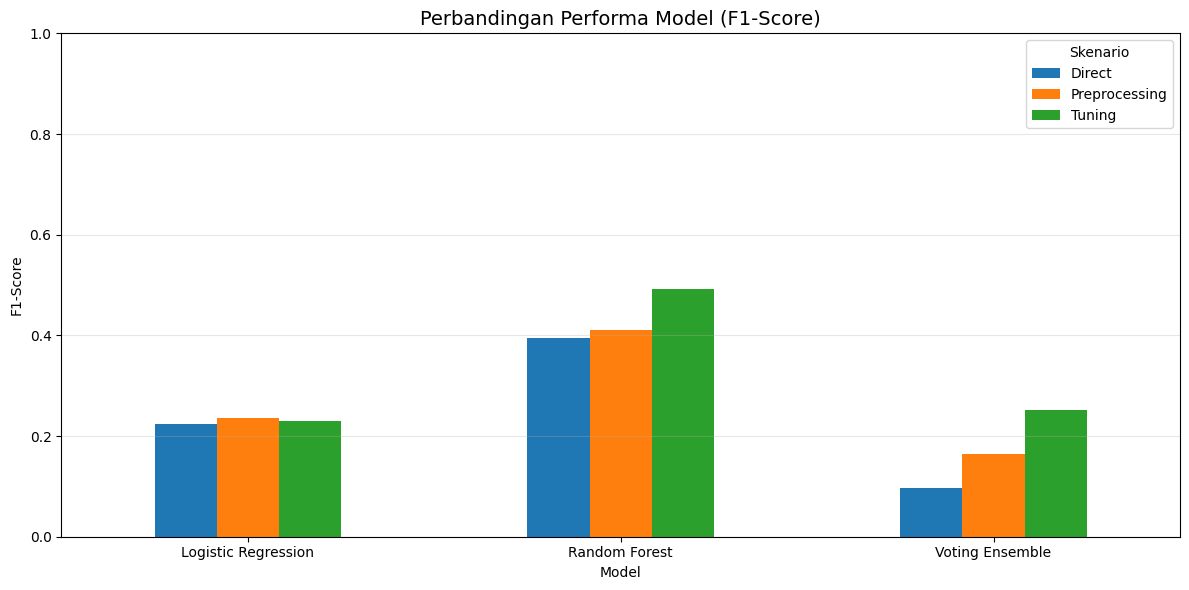


✅ Grafik disimpan: model_comparison.png


In [ ]:
print("\n" + "="*50)
print("📊 PERBANDINGAN AKHIR SEMUA SKENARIO")
print("="*50)

# Buat comparison dataframe
comparison_data = {}

# Direct modeling results
if 'results_direct' in locals():
    for model_name, metrics in results_direct.items():
        if model_name not in comparison_data:
            comparison_data[model_name] = {}
        comparison_data[model_name]['Direct'] = metrics.get('F1-Score', 0)

# Preprocessing results
if 'results_prep' in locals():
    for model_name, metrics in results_prep.items():
        if model_name not in comparison_data:
            comparison_data[model_name] = {}
        comparison_data[model_name]['Preprocessing'] = metrics.get('F1-Score', 0)

# Tuning results
if 'results_tuned' in locals():
    for model_name, metrics in results_tuned.items():
        if model_name not in comparison_data:
            comparison_data[model_name] = {}
        comparison_data[model_name]['Tuning'] = metrics.get('F1-Score', 0)

# Convert ke DataFrame
if comparison_data:
    comparison_df = pd.DataFrame(comparison_data).T
    print("\n📋 PERBANDINGAN F1-SCORE:")
    print(comparison_df.round(4))

    # Visualisasi
    if comparison_df.shape[1] > 0:
        comparison_df.plot(kind='bar', figsize=(12, 6))
        plt.title('Perbandingan Performa Model (F1-Score)', fontsize=14)
        plt.ylabel('F1-Score')
        plt.xlabel('Model')
        plt.legend(title='Skenario')
        plt.xticks(rotation=0)
        plt.ylim(0, 1)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.savefig('model_comparison.png', dpi=100)
        plt.show()
        print("\n✅ Grafik disimpan: model_comparison.png")
else:
    print("⚠️ Tidak ada data untuk perbandingan")